<a href="https://colab.research.google.com/github/RSC-SC/ML-MiniProj-Mod2/blob/feature%2Fissue6/ML_MiniProj_Mod2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML - Mini Projeto Modulo 2

##Sprint 1: Configuração e Versionamento:

In [2]:
# 1. Instalar a biblioteca gdown silenciosamente
!pip install gdown -q

import os
import zipfile
import gdown

# ID do arquivo no Google Drive
drive_file_id = '1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK'
output_filename = 'dataset.zip'

print(f"Baixando arquivo do Google Drive (ID: {drive_file_id})...")
# O gdown faz o download com base no ID
gdown.download(id=drive_file_id, output=output_filename, quiet=False)
print("Download concluído.\n")

# 2. Descompactar o arquivo .zip
dataset_dir = 'dataset'
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

print(f"Descompactando '{output_filename}' na pasta '{dataset_dir}/'...")
with zipfile.ZipFile(output_filename, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)
print("Descompactação finalizada.\n")

# 3. Validar e exibir a estrutura de pastas e subpastas
print("--- Estrutura de Pastas do Dataset ---")
expected_classes = ['def_front', 'ok_front']
found_classes = set()

for root, dirs, files in os.walk(dataset_dir):
    level = root.replace(dataset_dir, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📁 {os.path.basename(root) or dataset_dir}/")

    # Registra as classes encontradas
    for dir_name in dirs:
        if dir_name in expected_classes:
            found_classes.add(dir_name)

print("\n--- Validação das Classes ---")
if all(cls in found_classes for cls in expected_classes):
    print("✅ Todas as classes esperadas foram encontradas na estrutura.")
else:
    missing = [cls for cls in expected_classes if cls not in found_classes]
    print(f"⚠️ Atenção: As seguintes classes não foram encontradas: {missing}")

# 4. Imprimir a quantidade total de imagens
print("\n--- Contagem de Imagens ---")
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')

def count_images_in_dir(directory):
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(image_extensions):
                count += 1
    return count

# Se não houver pastas explícitas de train/test, conta de forma global por classe
for cls in found_classes:
    cls_total = 0
    for root, dirs, _ in os.walk(dataset_dir):
        if os.path.basename(root) == cls:
            cls_total += count_images_in_dir(root)
    print(f"  Total de imagens para a classe '{cls}': {cls_total}")

total_geral = count_images_in_dir(dataset_dir)
print(f"\nTotal geral de imagens no dataset: {total_geral}")

Baixando arquivo do Google Drive (ID: 1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK)...


Downloading...
From (original): https://drive.google.com/uc?id=1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK
From (redirected): https://drive.google.com/uc?id=1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK&confirm=t&uuid=cb5bcb9d-7900-41fe-8d4c-aaea01ca7e0e
To: /content/dataset.zip
100%|██████████| 32.2M/32.2M [00:02<00:00, 15.9MB/s]


Download concluído.

Descompactando 'dataset.zip' na pasta 'dataset/'...
Descompactação finalizada.

--- Estrutura de Pastas do Dataset ---
📁 dataset/
    📁 casting_512x512/
        📁 ok_front/
        📁 def_front/

--- Validação das Classes ---
✅ Todas as classes esperadas foram encontradas na estrutura.

--- Contagem de Imagens ---
  Total de imagens para a classe 'def_front': 781
  Total de imagens para a classe 'ok_front': 519

Total geral de imagens no dataset: 1300


##Sprint 2: Análise Exploratória Clássica (OpenCV):

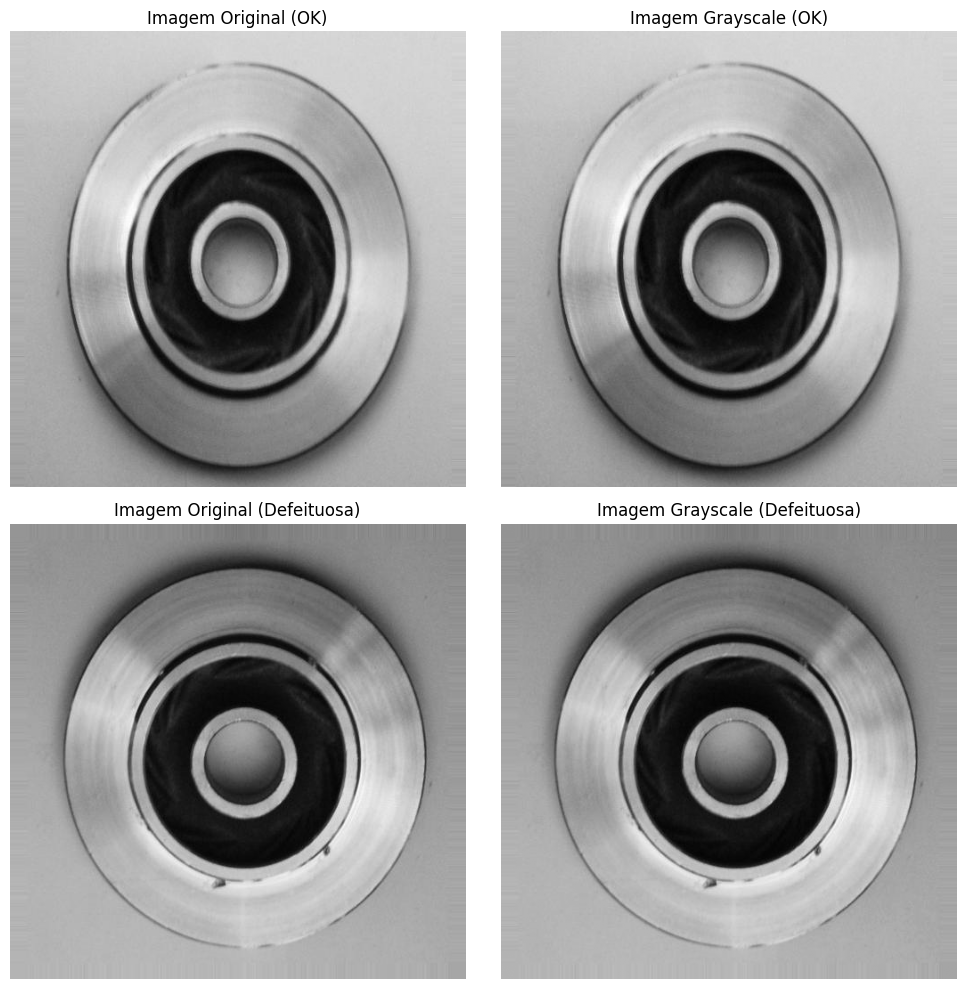

In [3]:
import cv2
import matplotlib.pyplot as plt
import os
import glob

# 1. Localizar e carregar automaticamente 2 imagens de amostra
# Caminhos baseados na estrutura descoberta anteriormente
path_ok = 'dataset/casting_512x512/ok_front/'
path_def = 'dataset/casting_512x512/def_front/'

# Pegar a primeira imagem de cada diretório
img_ok_path = glob.glob(os.path.join(path_ok, '*.*'))[0]
img_def_path = glob.glob(os.path.join(path_def, '*.*'))[0]

# Carregar as imagens usando OpenCV (o padrão é BGR)
img_ok_bgr = cv2.imread(img_ok_path)
img_def_bgr = cv2.imread(img_def_path)

# 2. Converter o espaço de cores de BGR para escala de cinza
img_ok_gray = cv2.cvtColor(img_ok_bgr, cv2.COLOR_BGR2GRAY)
img_def_gray = cv2.cvtColor(img_def_bgr, cv2.COLOR_BGR2GRAY)

# 3. Converter o espaço de cores de BGR para RGB para o Matplotlib
img_ok_rgb = cv2.cvtColor(img_ok_bgr, cv2.COLOR_BGR2RGB)
img_def_rgb = cv2.cvtColor(img_def_bgr, cv2.COLOR_BGR2RGB)

# 4. Exibir um painel comparativo 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Linha 1: Imagem OK (Original RGB vs Grayscale)
axes[0, 0].imshow(img_ok_rgb)
axes[0, 0].set_title('Imagem Original (OK)')
axes[0, 0].axis('off') # 5. Remover marcações dos eixos

axes[0, 1].imshow(img_ok_gray, cmap='gray')
axes[0, 1].set_title('Imagem Grayscale (OK)')
axes[0, 1].axis('off')

# Linha 2: Imagem Defeituosa (Original RGB vs Grayscale)
axes[1, 0].imshow(img_def_rgb)
axes[1, 0].set_title('Imagem Original (Defeituosa)')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_def_gray, cmap='gray')
axes[1, 1].set_title('Imagem Grayscale (Defeituosa)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


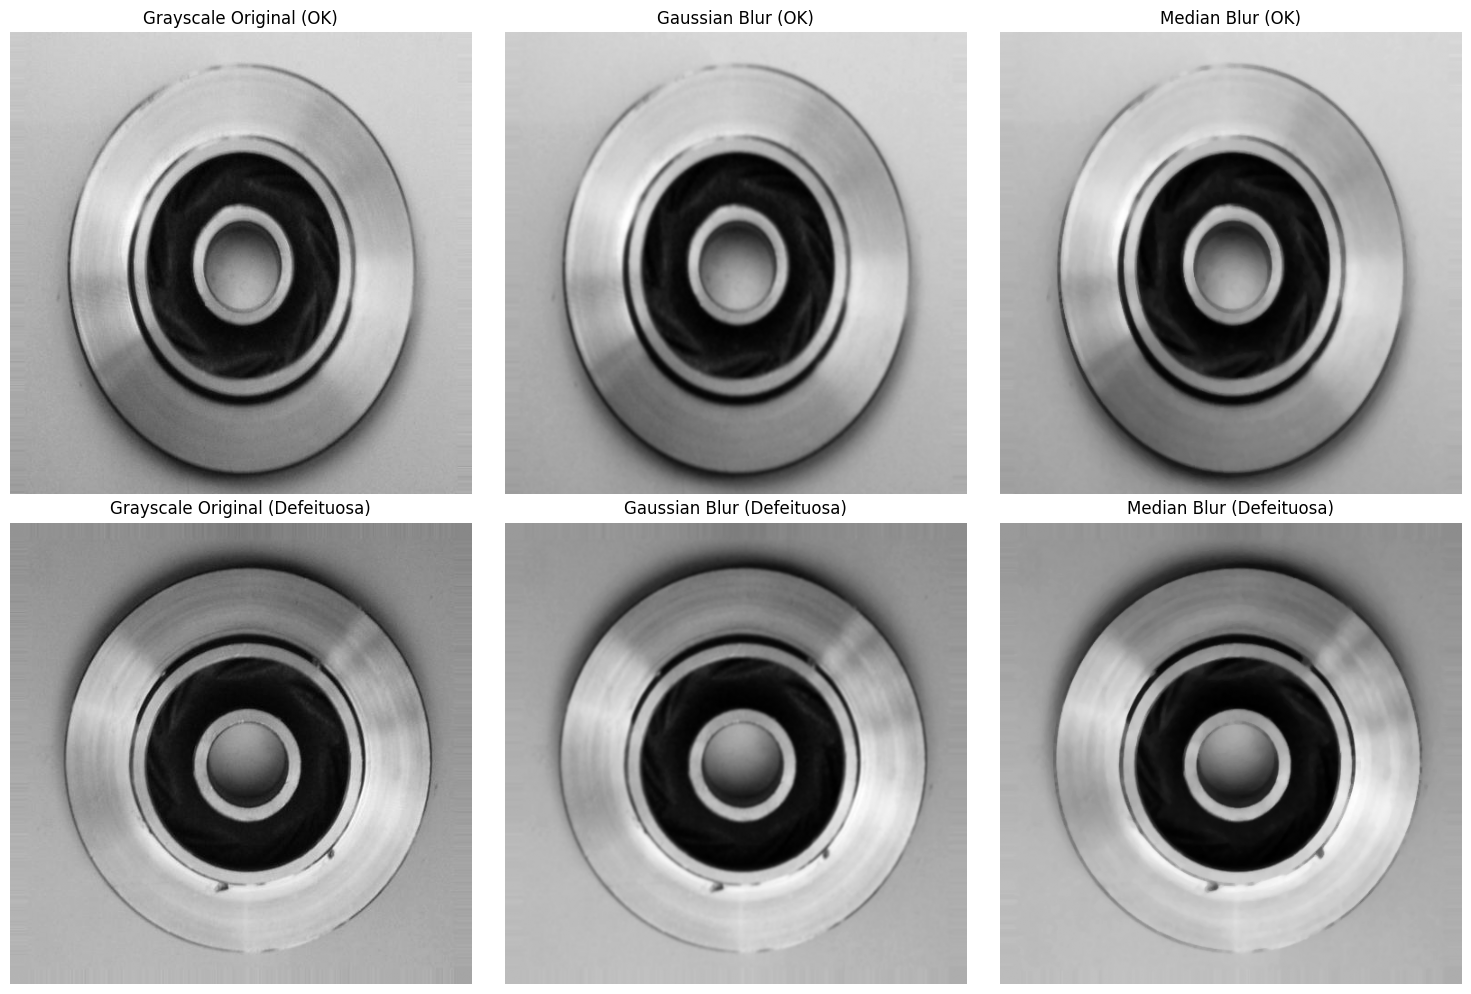

In [5]:
import cv2
import matplotlib.pyplot as plt

# 1. Utilizando as imagens já carregadas e convertidas na célula anterior:
# Variáveis: img_ok_gray e img_def_gray

# 2. Aplicar o filtro Gaussian Blur com kernel (5, 5)
img_ok_gaussian = cv2.GaussianBlur(img_ok_gray, (5, 5), 0)
img_def_gaussian = cv2.GaussianBlur(img_def_gray, (5, 5), 0)

# 3. Aplicar o filtro Median Blur com tamanho de abertura 5
img_ok_median = cv2.medianBlur(img_ok_gray, 5)
img_def_median = cv2.medianBlur(img_def_gray, 5)

# 4. Montar e exibir um painel comparativo 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Linha 1: OK
axes[0, 0].imshow(img_ok_gray, cmap='gray')
axes[0, 0].set_title('Grayscale Original (OK)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_ok_gaussian, cmap='gray')
axes[0, 1].set_title('Gaussian Blur (OK)')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_ok_median, cmap='gray')
axes[0, 2].set_title('Median Blur (OK)')
axes[0, 2].axis('off')

# Linha 2: Defeituosa
axes[1, 0].imshow(img_def_gray, cmap='gray')
axes[1, 0].set_title('Grayscale Original (Defeituosa)')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_def_gaussian, cmap='gray')
axes[1, 1].set_title('Gaussian Blur (Defeituosa)')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_def_median, cmap='gray')
axes[1, 2].set_title('Median Blur (Defeituosa)')
axes[1, 2].axis('off')

# Ajustar layout e exibir
plt.tight_layout()
plt.show()


##Sprint 3: Destaque de Características

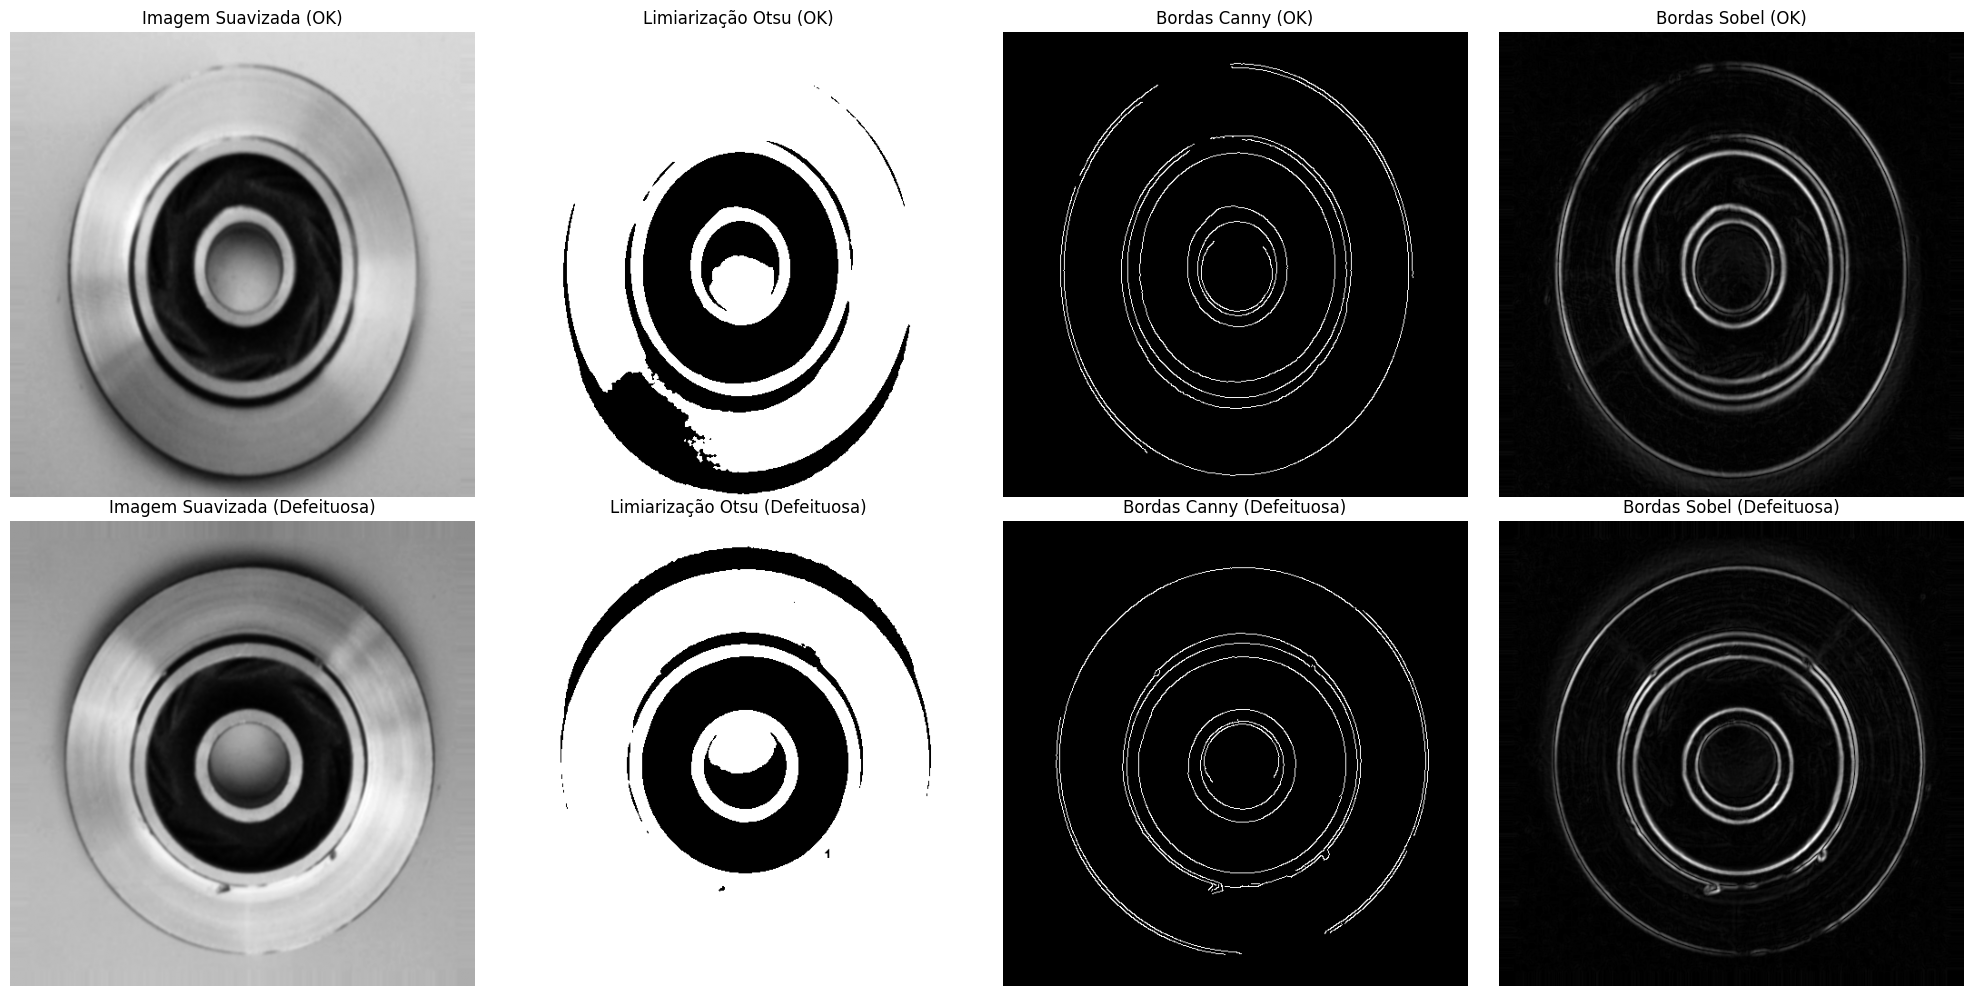

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 0. Requisito de Encadeamento: Utilizar imagens suavizadas da Issue #4
# As variáveis geradas na etapa anterior foram nomeadas 'img_ok_gaussian' e 'img_def_gaussian'
blur_ok = img_ok_gaussian
blur_def = img_def_gaussian

# 1. Limiarização de Otsu
_, otsu_ok = cv2.threshold(blur_ok, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_def = cv2.threshold(blur_def, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Algoritmo Canny (limiares 50 e 150)
canny_ok = cv2.Canny(blur_ok, 50, 150)
canny_def = cv2.Canny(blur_def, 50, 150)

# 3. Operador Sobel (eixos X e Y)
def apply_sobel(img):
    # Sobel no eixo X
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    # Sobel no eixo Y
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Converter de volta para uint8 (valores absolutos)
    sobelx_abs = cv2.convertScaleAbs(sobelx)
    sobely_abs = cv2.convertScaleAbs(sobely)

    # Combinar as magnitudes com pesos iguais
    sobel_combined = cv2.addWeighted(sobelx_abs, 0.5, sobely_abs, 0.5, 0)
    return sobel_combined

sobel_ok = apply_sobel(blur_ok)
sobel_def = apply_sobel(blur_def)

# 4. Montar e exibir um painel comparativo 2x4
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# --- Linha 1: Amostra OK ---
axes[0, 0].imshow(blur_ok, cmap='gray')
axes[0, 0].set_title('Imagem Suavizada (OK)')
axes[0, 0].axis('off')

axes[0, 1].imshow(otsu_ok, cmap='gray')
axes[0, 1].set_title('Limiarização Otsu (OK)')
axes[0, 1].axis('off')

axes[0, 2].imshow(canny_ok, cmap='gray')
axes[0, 2].set_title('Bordas Canny (OK)')
axes[0, 2].axis('off')

axes[0, 3].imshow(sobel_ok, cmap='gray')
axes[0, 3].set_title('Bordas Sobel (OK)')
axes[0, 3].axis('off')

# --- Linha 2: Amostra Defeituosa ---
axes[1, 0].imshow(blur_def, cmap='gray')
axes[1, 0].set_title('Imagem Suavizada (Defeituosa)')
axes[1, 0].axis('off')

axes[1, 1].imshow(otsu_def, cmap='gray')
axes[1, 1].set_title('Limiarização Otsu (Defeituosa)')
axes[1, 1].axis('off')

axes[1, 2].imshow(canny_def, cmap='gray')
axes[1, 2].set_title('Bordas Canny (Defeituosa)')
axes[1, 2].axis('off')

axes[1, 3].imshow(sobel_def, cmap='gray')
axes[1, 3].set_title('Bordas Sobel (Defeituosa)')
axes[1, 3].axis('off')

# Ajustar o layout e exibir (5. Títulos claros e eixos removidos)
plt.tight_layout()
plt.show()


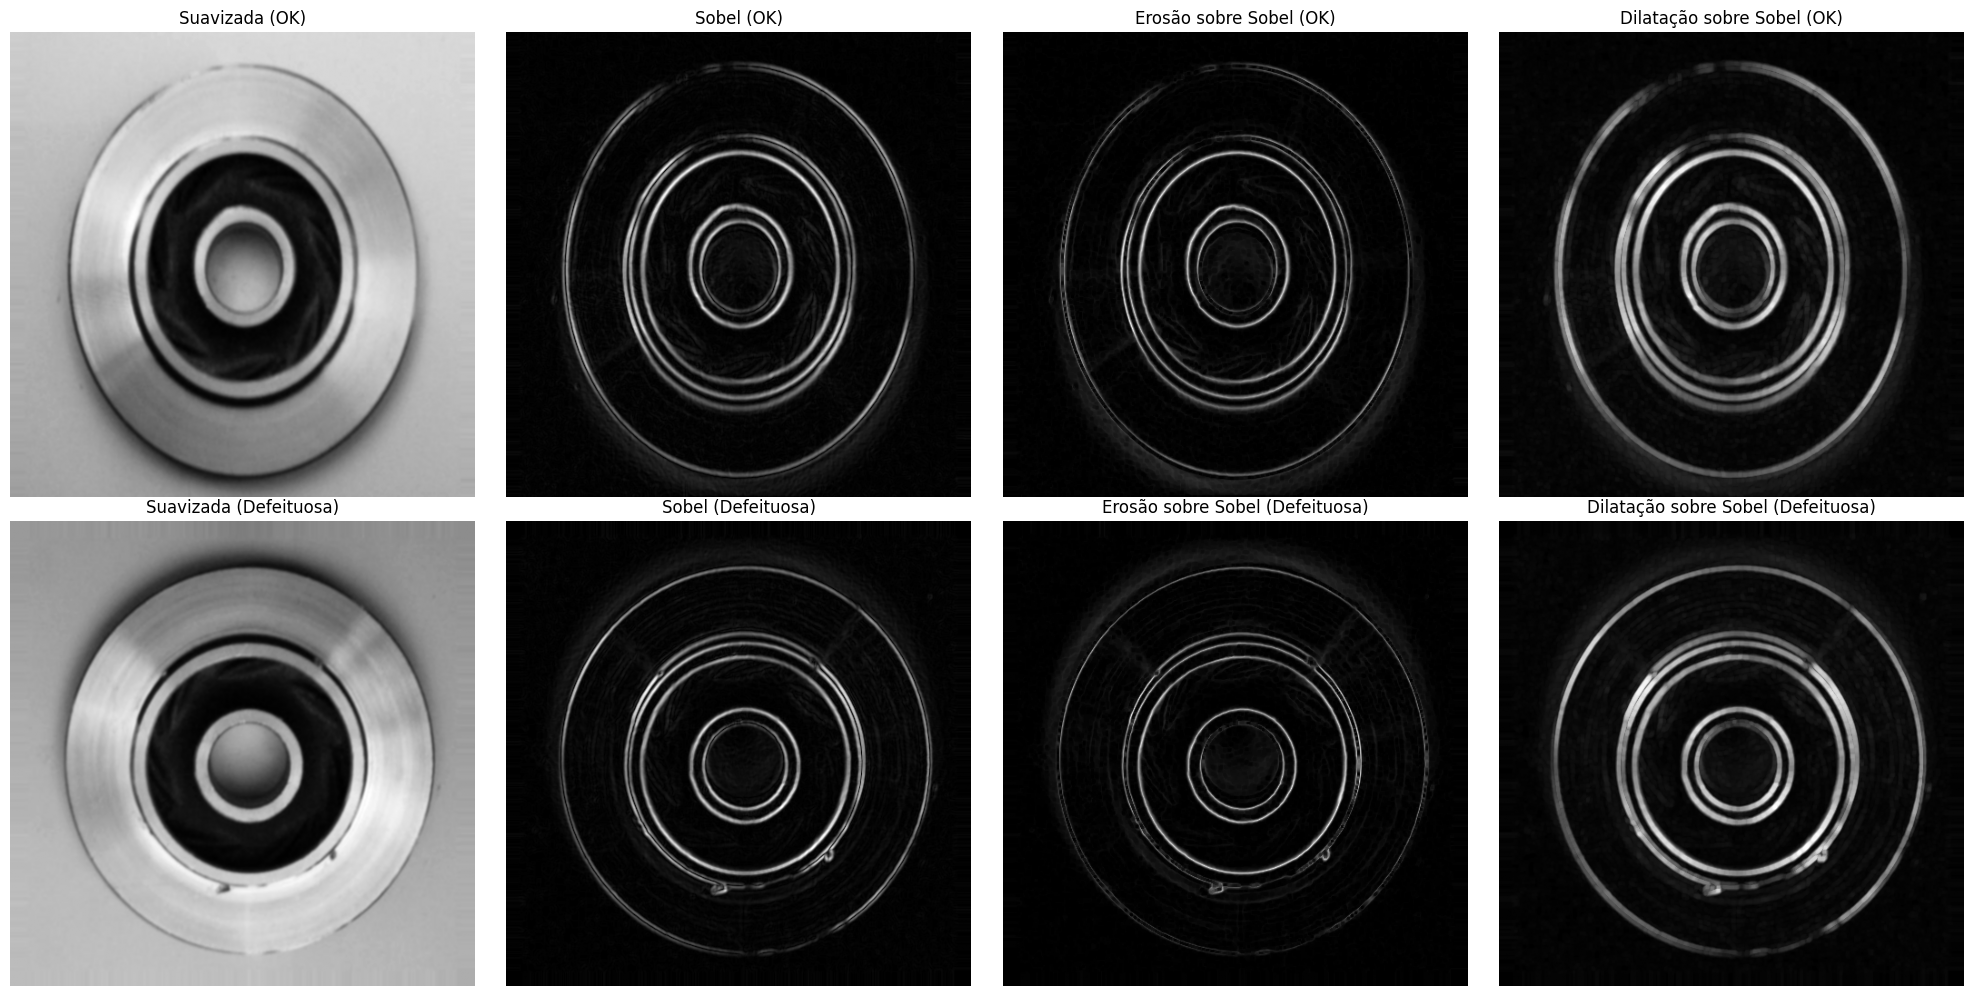

In [9]:
import cv2
import matplotlib.pyplot as plt

# 1. Definir o kernel 3x3
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Base: Sobel (da Issue #5)
base_ok_sobel = sobel_ok
base_def_sobel = sobel_def

# 2. Erosão e Dilatação sobre o Sobel
eroded_ok_sobel = cv2.erode(base_ok_sobel, kernel, iterations=1)
eroded_def_sobel = cv2.erode(base_def_sobel, kernel, iterations=1)

dilated_ok_sobel = cv2.dilate(base_ok_sobel, kernel, iterations=1)
dilated_def_sobel = cv2.dilate(base_def_sobel, kernel, iterations=1)

# 3. Plotagem do painel 2x4
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# --- Linha OK ---
axes[0, 0].imshow(blur_ok, cmap='gray')
axes[0, 0].set_title('Suavizada (OK)')
axes[0, 0].axis('off')

axes[0, 1].imshow(base_ok_sobel, cmap='gray')
axes[0, 1].set_title('Sobel (OK)')
axes[0, 1].axis('off')

axes[0, 2].imshow(eroded_ok_sobel, cmap='gray')
axes[0, 2].set_title('Erosão sobre Sobel (OK)')
axes[0, 2].axis('off')

axes[0, 3].imshow(dilated_ok_sobel, cmap='gray')
axes[0, 3].set_title('Dilatação sobre Sobel (OK)')
axes[0, 3].axis('off')

# --- Linha Defeituosa ---
axes[1, 0].imshow(blur_def, cmap='gray')
axes[1, 0].set_title('Suavizada (Defeituosa)')
axes[1, 0].axis('off')

axes[1, 1].imshow(base_def_sobel, cmap='gray')
axes[1, 1].set_title('Sobel (Defeituosa)')
axes[1, 1].axis('off')

axes[1, 2].imshow(eroded_def_sobel, cmap='gray')
axes[1, 2].set_title('Erosão sobre Sobel (Defeituosa)')
axes[1, 2].axis('off')

axes[1, 3].imshow(dilated_def_sobel, cmap='gray')
axes[1, 3].set_title('Dilatação sobre Sobel (Defeituosa)')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()
